# CMB B-mode Fisher Forecast: Quickstart

This notebook walks through the core workflow of the `augr` package:

1. Define an instrument (frequency channels, detectors, noise)
2. Set up a foreground model and CMB spectra
3. Build the signal model and bandpower covariance
4. Compute the Fisher matrix and extract $\sigma(r)$
5. Explore how $\sigma(r)$ depends on delensing, frequency coverage, and noise

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from augr.instrument import Channel, Instrument, ScalarEfficiency, white_noise_power, noise_nl, ARCMIN_TO_RAD
from augr.foregrounds import GaussianForegroundModel
from augr.spectra import CMBSpectra
from augr.signal import SignalModel, flatten_params
from augr.fisher import FisherForecast
from augr.config import FIDUCIAL_BK15, pico_like, litebird_like, simple_probe, so_like, cmbs4_like


## 1. Instrument presets

The package includes three built-in instrument configurations. Let's start with the simple 6-band probe.

In [2]:
inst = simple_probe()

print(f"Channels: {len(inst.channels)}")
print(f"Mission: {inst.mission_duration_years} yr, f_sky = {inst.f_sky}")
print()
header = f"{'Freq [GHz]':>12} {'N_det':>8} {'NET [uK*sqrt(s)]':>18} {'Beam [arcmin]':>14} {'Depth [uK-arcmin]':>18}"
print(header)
print("-" * len(header))
for ch in inst.channels:
    depth = np.sqrt(float(white_noise_power(ch, inst.mission_duration_years, inst.f_sky))) / float(ARCMIN_TO_RAD)
    print(f"{ch.nu_ghz:12.0f} {ch.n_detectors:8d} {ch.net_per_detector:18.1f} {ch.beam_fwhm_arcmin:14.1f} {depth:18.2f}")

Channels: 6
Mission: 5.0 yr, f_sky = 0.7

  Freq [GHz]    N_det   NET [uK*sqrt(s)]  Beam [arcmin]  Depth [uK-arcmin]
--------------------------------------------------------------------------
          30       12              114.0           38.4              48.80
          90       48               52.0           12.8              11.13
         150       96               43.0            7.7               6.51
         220       96               65.0            5.3               9.84
         340       48              199.0            3.4              42.59
         500       12              930.0            2.3             398.12


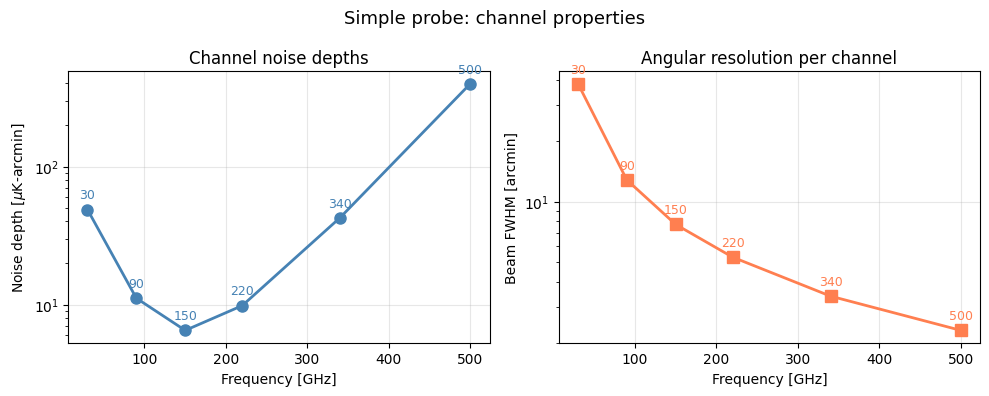

In [3]:
# Channel properties: noise depth and angular resolution vs frequency
freqs  = np.array([ch.nu_ghz for ch in inst.channels])
depths = np.array([
    np.sqrt(float(white_noise_power(ch, inst.mission_duration_years, inst.f_sky))) / float(ARCMIN_TO_RAD)
    for ch in inst.channels
])
beams  = np.array([ch.beam_fwhm_arcmin for ch in inst.channels])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.semilogy(freqs, depths, 'o-', color='steelblue', ms=8, lw=2)
ax1.set_xlabel('Frequency [GHz]')
ax1.set_ylabel(r'Noise depth [$\mu$K-arcmin]')
ax1.set_title('Channel noise depths')
ax1.grid(True, alpha=0.3)
for f, d in zip(freqs, depths):
    ax1.annotate(f'{f:.0f}', (f, d), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=9, color='steelblue')

ax2.semilogy(freqs, beams, 's-', color='coral', ms=8, lw=2)
ax2.set_xlabel('Frequency [GHz]')
ax2.set_ylabel('Beam FWHM [arcmin]')
ax2.set_title('Angular resolution per channel')
ax2.grid(True, alpha=0.3)
for f, b in zip(freqs, beams):
    ax2.annotate(f'{f:.0f}', (f, b), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=9, color='coral')

plt.suptitle('Simple probe: channel properties', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Signal model and foreground spectra

The signal model assembles the data vector $\mu(\theta)$: binned bandpowers across all
unique cross-frequency spectra. The CMB and foreground spectra that go into it are
worth visualizing to understand what we are fitting.

In [4]:
fg_model = GaussianForegroundModel()
cmb = CMBSpectra()

# Signal model: data vector = CMB(r, A_lens) + foregrounds(params) at each (freq_i, freq_j, ell_bin)
signal = SignalModel(
    inst, fg_model, cmb,
    ell_min=2, ell_max=300,
    delta_ell=30, ell_per_bin_below=10,
)

print(f"Data vector length: {signal.n_data}")
print(f"Parameters: {signal.parameter_names}")
print(f"Number of ell bins: {len(signal.bin_centers)}")
print(f"Bin centers: {[f'{b:.0f}' for b in signal.bin_centers]}")

Data vector length: 378
Parameters: ['r', 'A_lens', 'A_dust', 'beta_dust', 'alpha_dust', 'T_dust', 'A_sync', 'beta_sync', 'alpha_sync', 'epsilon', 'Delta_dust']
Number of ell bins: 18
Bin centers: ['2', '3', '4', '5', '6', '7', '8', '9', '24', '54', '84', '114', '144', '174', '204', '234', '264', '290']


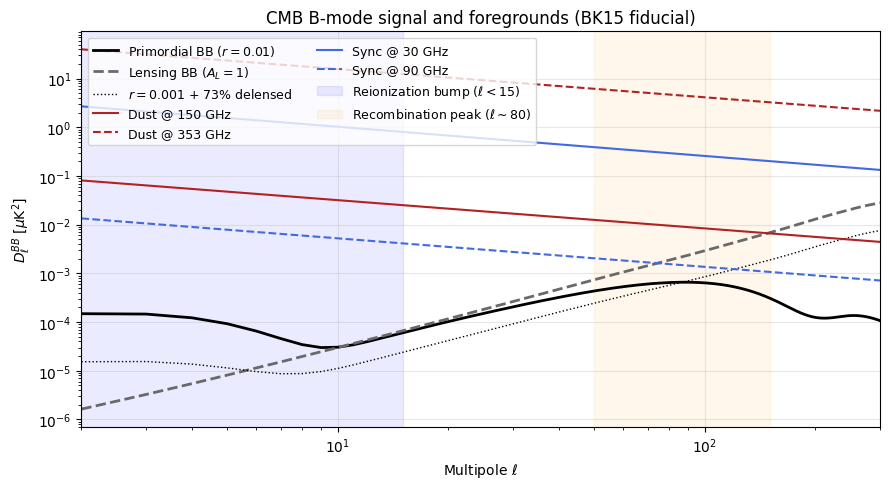

In [5]:
# Visualize the CMB B-mode signal components and foreground spectra
ells_np  = np.arange(2, 301, dtype=float)
ells_jax = jnp.array(ells_np)
Dl_fac   = ells_np * (ells_np + 1) / (2 * np.pi)  # C_ell -> D_ell

# CMB spectra: primordial (r=0.01), lensing-only, and total
cl_prim  = np.array(cmb.cl_bb(ells_jax, r=0.01,  A_lens=0.0))   # pure primordial
cl_lens  = np.array(cmb.cl_bb(ells_jax, r=0.0,   A_lens=1.0))   # pure lensing
cl_total = np.array(cmb.cl_bb(ells_jax, r=0.001, A_lens=0.27))  # r=0.001 + 73% delensed

# Foreground spectra at BK15 fiducial
params_vec = flatten_params(FIDUCIAL_BK15, signal.parameter_names)
fg_params  = params_vec[2:]
cl_dust_150 = np.array(fg_model.cl_bb(150.0, 150.0, ells_jax, fg_params))
cl_dust_353 = np.array(fg_model.cl_bb(353.0, 353.0, ells_jax, fg_params))
cl_sync_30  = np.array(fg_model.cl_bb( 30.0,  30.0, ells_jax, fg_params))
cl_sync_90  = np.array(fg_model.cl_bb( 90.0,  90.0, ells_jax, fg_params))

fig, ax = plt.subplots(figsize=(9, 5))

ax.loglog(ells_np, Dl_fac * cl_prim,   color='black',      lw=2.0, label=r'Primordial BB ($r=0.01$)')
ax.loglog(ells_np, Dl_fac * cl_lens,   color='dimgray',    lw=2.0, ls='--',  label=r'Lensing BB ($A_L=1$)')
ax.loglog(ells_np, Dl_fac * cl_total,  color='black',      lw=1.0, ls=':',   label=r'$r=0.001$ + 73% delensed')
ax.loglog(ells_np, Dl_fac * cl_dust_150, color='firebrick', lw=1.5, label='Dust @ 150 GHz')
ax.loglog(ells_np, Dl_fac * cl_dust_353, color='firebrick', lw=1.5, ls='--', label='Dust @ 353 GHz')
ax.loglog(ells_np, Dl_fac * cl_sync_30,  color='royalblue', lw=1.5, label='Sync @ 30 GHz')
ax.loglog(ells_np, Dl_fac * cl_sync_90,  color='royalblue', lw=1.5, ls='--', label='Sync @ 90 GHz')

# Shade key ell ranges
ax.axvspan(2,  15,  alpha=0.08, color='blue',   label=r'Reionization bump ($\ell < 15$)')
ax.axvspan(50, 150, alpha=0.08, color='orange', label=r'Recombination peak ($\ell \sim 80$)')

ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell^{BB}$ [$\mu$K$^2$]')
ax.set_title('CMB B-mode signal and foregrounds (BK15 fiducial)')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(2, 300)
plt.tight_layout()
plt.show()

## 3. Basic forecast

Set up the Fisher forecast with BK15 fiducial foreground parameters, beta priors from
Planck, and $A_L = 1$ (no delensing). The first call triggers JIT compilation of the
Jacobian; subsequent calls reuse the compiled code.

In [6]:
# Fiducial parameters (BK15 maximum-likelihood foreground values)
fid = dict(FIDUCIAL_BK15)

# Fisher forecast: marginalize over foreground parameters, apply priors
ff = FisherForecast(
    signal, inst, fid,
    priors={"beta_dust": 0.11, "beta_sync": 0.3},
    fixed_params=["T_dust", "Delta_dust"],
)

print(f"sigma(r) = {ff.sigma('r'):.2e}")
print(f"sigma(r) conditional = {ff.sigma_conditional('r'):.2e}")

sigma(r) = 1.68e-04
sigma(r) conditional = 1.67e-04


## 4. Effect of delensing

The lensing B-mode is the dominant noise floor for sensitive experiments.
`A_lens` scales the lensing BB power spectrum: `A_lens=1` is the standard $\Lambda$CDM
lensing level (no delensing), `A_lens=0.27` means 73% delensing (PICO baseline),
`A_lens=0` is perfect delensing. These calls to FisherForecast reuse the JIT-compiled
Jacobian from above.

  A_lens=1.00 (0% delensing): sigma(r) = 1.68e-04
  A_lens=0.50 (50% delensing): sigma(r) = 1.35e-04
  A_lens=0.27 (73% delensing): sigma(r) = 1.19e-04
  A_lens=0.15 (85% delensing): sigma(r) = 1.11e-04
  A_lens=0.05 (95% delensing): sigma(r) = 1.05e-04


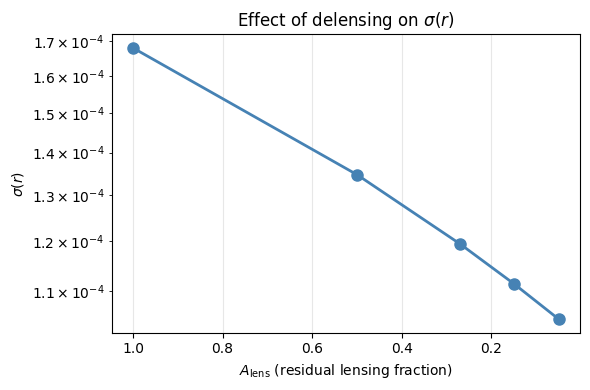

In [7]:
A_lens_values = [1.0, 0.5, 0.27, 0.15, 0.05]
sigma_r = []

for A_L in A_lens_values:
    fid_dl = dict(FIDUCIAL_BK15)
    fid_dl["A_lens"] = A_L
    ff_dl = FisherForecast(
        signal, inst, fid_dl,
        priors={"beta_dust": 0.11, "beta_sync": 0.3},
        fixed_params=["T_dust", "Delta_dust"],
    )
    sr = ff_dl.sigma("r")
    sigma_r.append(sr)
    delens_pct = (1 - A_L) * 100
    print(f"  A_lens={A_L:.2f} ({delens_pct:.0f}% delensing): sigma(r) = {sr:.2e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(A_lens_values, sigma_r, 'o-', color='steelblue', ms=8, lw=2)
ax.set_xlabel(r'$A_{\mathrm{lens}}$ (residual lensing fraction)')
ax.set_ylabel(r'$\sigma(r)$')
ax.set_title(r'Effect of delensing on $\sigma(r)$')
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Comparing instrument presets

Compare five instrument configurations: three space missions and two ground-based
experiments. The noise depth plot reveals each experiment's spectral coverage
and sensitivity floor. The delensing curves show how $\sigma(r)$ scales with
residual lensing for each.

Ground-based experiments lose access to $\ell < 30$ (atmospheric noise) and
cannot observe above ~280 GHz. Space missions cover the full $\ell$ range
including the reionization bump and have high-frequency dust channels.
1/f atmospheric noise is not modeled here, so ground forecasts are optimistic
below $\ell \approx 50$.

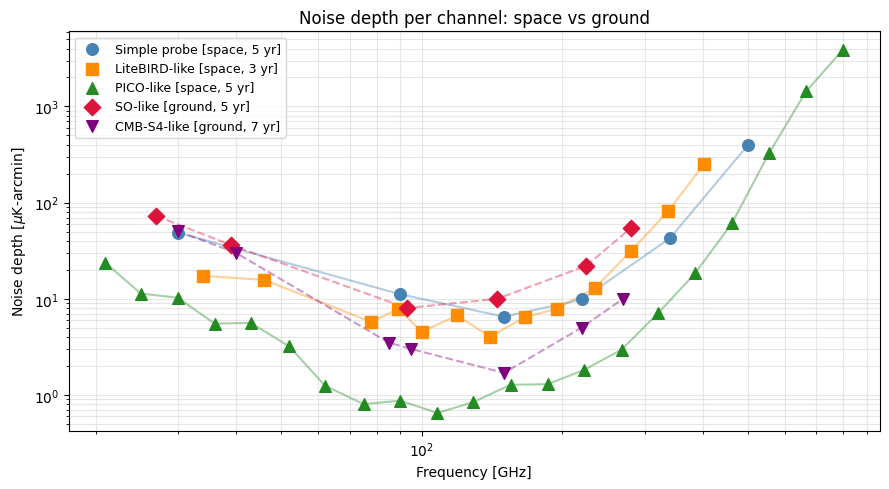

In [8]:
# --- Noise depth comparison ---
# preset_list entries: (label, instrument, ell_min)
# ell_min=2 for space (full sky access), ell_min=30 for ground (atmosphere)
preset_list = [
    ("Simple probe [space, 5 yr]",   simple_probe(),   2),
    ("LiteBIRD-like [space, 3 yr]",  litebird_like(),  2),
    ("PICO-like [space, 5 yr]",      pico_like(),      2),
    ("SO-like [ground, 5 yr]",       so_like(),       30),
    ("CMB-S4-like [ground, 7 yr]",   cmbs4_like(),    30),
]
space_colors  = ['steelblue', 'darkorange', 'forestgreen']
ground_colors = ['crimson', 'purple']
all_colors    = space_colors + ground_colors
markers = ['o', 's', '^', 'D', 'v']

fig, ax = plt.subplots(figsize=(9, 5))
for (label, inst_p, _), color, marker in zip(preset_list, all_colors, markers):
    freqs_p = [ch.nu_ghz for ch in inst_p.channels]
    depths_p = [
        np.sqrt(float(white_noise_power(ch, inst_p.mission_duration_years, inst_p.f_sky))) / float(ARCMIN_TO_RAD)
        for ch in inst_p.channels
    ]
    ls = '-' if '[space' in label else '--'
    ax.scatter(freqs_p, depths_p, color=color, marker=marker, s=70, label=label, zorder=5)
    ax.plot(freqs_p, depths_p, ls, color=color, alpha=0.4, lw=1.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel(r'Noise depth [$\mu$K-arcmin]')
ax.set_title('Noise depth per channel: space vs ground')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()


  Simple probe [space, 5 yr]: compiling... done.  sigma(r) at 73% delensing = 1.19e-04
  LiteBIRD-like [space, 3 yr]: compiling... done.  sigma(r) at 73% delensing = 4.84e-05
  PICO-like [space, 5 yr]: compiling... done.  sigma(r) at 73% delensing = 1.85e-05
  SO-like [ground, 5 yr]: compiling... done.  sigma(r) at 73% delensing = 1.65e-03
  CMB-S4-like [ground, 7 yr]: compiling... done.  sigma(r) at 73% delensing = 2.68e-04


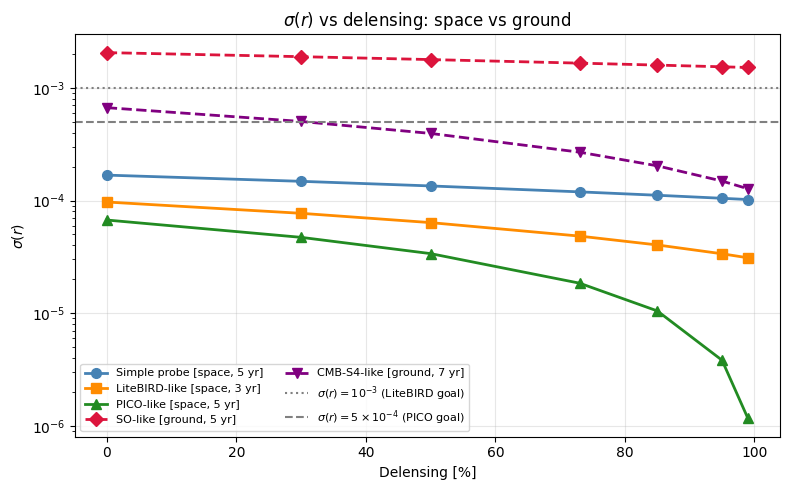

In [9]:
# --- sigma(r) vs delensing for all presets ---
# Space presets use ell_min=2 (reion bump included).
# Ground presets use ell_min=30 (atmosphere blocks lower ell).
# JIT is on per preset: compile once, sweep over A_lens.
A_lens_grid = np.array([1.0, 0.7, 0.5, 0.27, 0.15, 0.05, 0.01])
delens_pct   = (1 - A_lens_grid) * 100

fig, ax = plt.subplots(figsize=(8, 5))

for (label, inst_p, ell_min_p), color, marker in zip(preset_list, all_colors, markers):
    signal_p = SignalModel(
        inst_p, GaussianForegroundModel(), CMBSpectra(),
        ell_min=ell_min_p, ell_max=300, delta_ell=30, ell_per_bin_below=10,
        use_jit=True,  # compile once, reused across A_lens sweep
    )
    print(f'  {label}: compiling...', end=' ', flush=True)
    sr_list = []
    for A_L in A_lens_grid:
        fid_p = dict(FIDUCIAL_BK15)
        fid_p['A_lens'] = float(A_L)
        ff_p = FisherForecast(
            signal_p, inst_p, fid_p,
            priors={'beta_dust': 0.11, 'beta_sync': 0.3},
            fixed_params=['T_dust', 'Delta_dust'],
        )
        sr_list.append(ff_p.sigma('r'))
    print(f'done.  sigma(r) at 73% delensing = {sr_list[3]:.2e}')
    ls = '-' if '[space' in label else '--'
    ax.semilogy(delens_pct, sr_list, marker + ls, color=color,
                label=label, ms=7, lw=2)

# Reference targets
ax.axhline(1e-3, color='gray', ls=':',  lw=1.5, label=r'$\sigma(r)=10^{-3}$ (LiteBIRD goal)')
ax.axhline(5e-4, color='gray', ls='--', lw=1.5, label=r'$\sigma(r)=5\times10^{-4}$ (PICO goal)')

ax.set_xlabel('Delensing [%]')
ax.set_ylabel(r'$\sigma(r)$')
ax.set_title(r'$\sigma(r)$ vs delensing: space vs ground')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Detector count and survey time scaling

How does $\sigma(r)$ scale with instrument size? In the noise-dominated regime
we expect $\sigma(r) \propto 1/\sqrt{N_{\mathrm{det}}}$ (more detectors → lower
noise → better constraint). Foreground marginalization can create a floor
where the scaling saturates.

    190 detectors: sigma(r) = 2.14e-04
    475 detectors: sigma(r) = 9.64e-05
    950 detectors: sigma(r) = 5.72e-05
   1900 detectors: sigma(r) = 3.76e-05
   3800 detectors: sigma(r) = 2.78e-05
   7600 detectors: sigma(r) = 2.29e-05
  15200 detectors: sigma(r) = 2.05e-05


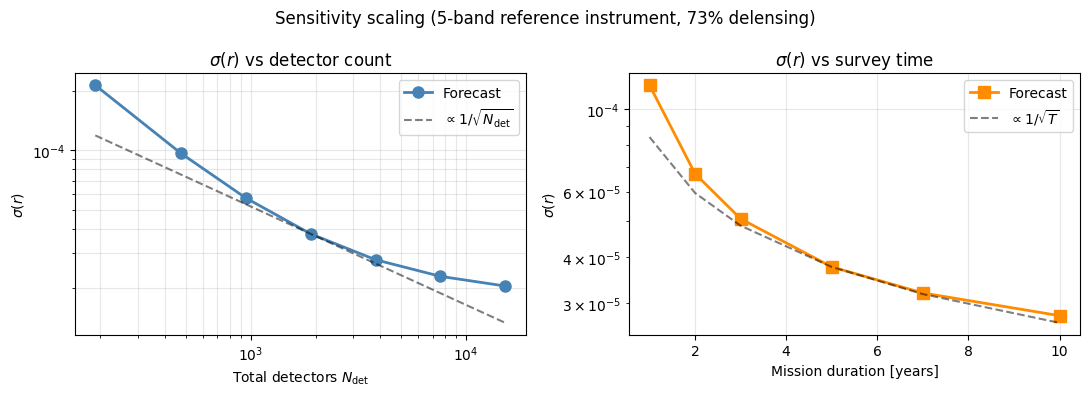

In [10]:
eff = ScalarEfficiency(
    detector_yield=0.85, observing_efficiency=0.85,
    data_cut_fraction=0.90, cosmic_ray_deadtime=0.97,
    polarization_efficiency=0.95,
)

# Reference 5-band instrument
channels_ref = (
    Channel(nu_ghz= 30.0, n_detectors=100, net_per_detector=120.0, beam_fwhm_arcmin=30.0, efficiency=eff),
    Channel(nu_ghz= 90.0, n_detectors=500, net_per_detector= 50.0, beam_fwhm_arcmin=10.0, efficiency=eff),
    Channel(nu_ghz=150.0, n_detectors=500, net_per_detector= 45.0, beam_fwhm_arcmin= 7.0, efficiency=eff),
    Channel(nu_ghz=220.0, n_detectors=500, net_per_detector= 70.0, beam_fwhm_arcmin= 5.0, efficiency=eff),
    Channel(nu_ghz=340.0, n_detectors=300, net_per_detector=200.0, beam_fwhm_arcmin= 3.5, efficiency=eff),
)
n_det_ref = sum(ch.n_detectors for ch in channels_ref)

# Sweep: scale all detector counts by a common factor
scale_factors = [0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
n_dets_total  = []
sigma_r_det   = []

for scale in scale_factors:
    channels_sc = tuple(
        Channel(nu_ghz=ch.nu_ghz,
                n_detectors=max(4, int(ch.n_detectors * scale)),
                net_per_detector=ch.net_per_detector,
                beam_fwhm_arcmin=ch.beam_fwhm_arcmin,
                efficiency=ch.efficiency)
        for ch in channels_ref
    )
    inst_sc = Instrument(channels=channels_sc, mission_duration_years=5.0, f_sky=0.7)
    signal_sc = SignalModel(
        inst_sc, GaussianForegroundModel(), CMBSpectra(),
        ell_min=2, ell_max=300, delta_ell=30, ell_per_bin_below=10,
        use_jit=False,  # each only run once
    )
    fid_sc = dict(FIDUCIAL_BK15)
    fid_sc["A_lens"] = 0.27
    ff_sc = FisherForecast(
        signal_sc, inst_sc, fid_sc,
        priors={"beta_dust": 0.11, "beta_sync": 0.3},
        fixed_params=["T_dust", "Delta_dust"],
    )
    n_tot = sum(ch.n_detectors for ch in channels_sc)
    n_dets_total.append(n_tot)
    sigma_r_det.append(ff_sc.sigma("r"))
    print(f"  {n_tot:5d} detectors: sigma(r) = {ff_sc.sigma('r'):.2e}")

# Also sweep survey duration at reference detector count
t_years = [1, 2, 3, 5, 7, 10]
sigma_r_time = []

for t in t_years:
    inst_t = Instrument(channels=channels_ref, mission_duration_years=t, f_sky=0.7)
    signal_t = SignalModel(
        inst_t, GaussianForegroundModel(), CMBSpectra(),
        ell_min=2, ell_max=300, delta_ell=30, ell_per_bin_below=10,
        use_jit=False,
    )
    fid_t = dict(FIDUCIAL_BK15)
    fid_t["A_lens"] = 0.27
    ff_t = FisherForecast(
        signal_t, inst_t, fid_t,
        priors={"beta_dust": 0.11, "beta_sync": 0.3},
        fixed_params=["T_dust", "Delta_dust"],
    )
    sigma_r_time.append(ff_t.sigma("r"))

# Plots
n_ref_idx = scale_factors.index(1.0)
sr_ref    = sigma_r_det[n_ref_idx]
n_ref     = n_dets_total[n_ref_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.loglog(n_dets_total, sigma_r_det, 'o-', color='steelblue', ms=8, lw=2, label='Forecast')
ax1.loglog(n_dets_total,
           [sr_ref * np.sqrt(n_ref / N) for N in n_dets_total],
           'k--', alpha=0.5, lw=1.5, label=r'$\propto 1/\sqrt{N_{\rm det}}$')
ax1.set_xlabel(r'Total detectors $N_{\rm det}$')
ax1.set_ylabel(r'$\sigma(r)$')
ax1.set_title(r'$\sigma(r)$ vs detector count')
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')

sr_t_ref = sigma_r_time[t_years.index(5)]
ax2.semilogy(t_years, sigma_r_time, 's-', color='darkorange', ms=8, lw=2, label='Forecast')
ax2.semilogy(t_years,
             [sr_t_ref * np.sqrt(5.0 / t) for t in t_years],
             'k--', alpha=0.5, lw=1.5, label=r'$\propto 1/\sqrt{T}$')
ax2.set_xlabel('Mission duration [years]')
ax2.set_ylabel(r'$\sigma(r)$')
ax2.set_title(r'$\sigma(r)$ vs survey time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Sensitivity scaling (5-band reference instrument, 73% delensing)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Reionization bump

Space missions access the reionization bump at $\ell < 20$, invisible from the ground.
Compare forecasts with and without low-$\ell$ access.

  Full ($\ell \geq 2$, with reion bump): sigma(r) = 1.19e-04
  Recomb. only ($\ell \geq 20$): sigma(r) = 6.36e-04

Gain from reionization bump: 5.3x


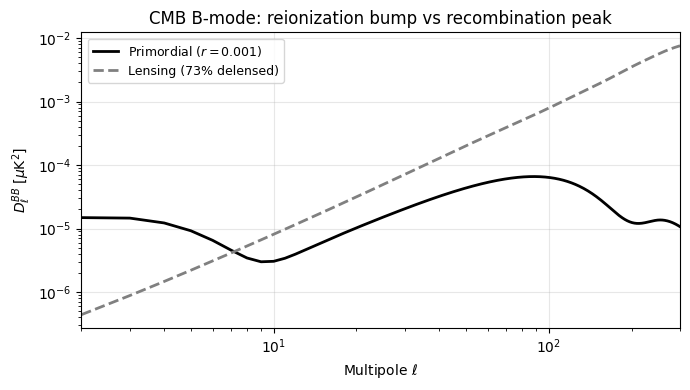

In [11]:
inst_reion = simple_probe()

results_reion = {}
for ell_min, label in [(2,  r'Full ($\ell \geq 2$, with reion bump)'),
                        (20, r'Recomb. only ($\ell \geq 20$)')]:
    signal_ell = SignalModel(
        inst_reion, GaussianForegroundModel(), CMBSpectra(),
        ell_min=ell_min, ell_max=300, delta_ell=30, ell_per_bin_below=10,
        use_jit=False,
    )
    fid_ell = dict(FIDUCIAL_BK15)
    fid_ell['A_lens'] = 0.27
    ff_ell = FisherForecast(
        signal_ell, inst_reion, fid_ell,
        priors={'beta_dust': 0.11, 'beta_sync': 0.3},
        fixed_params=['T_dust', 'Delta_dust'],
    )
    results_reion[label] = ff_ell.sigma('r')
    print(f'  {label}: sigma(r) = {ff_ell.sigma("r"):.2e}')

print(f'\nGain from reionization bump: '
      f'{list(results_reion.values())[1] / list(results_reion.values())[0]:.1f}x')

ells_np2  = np.arange(2, 301, dtype=float)
ells_jax2 = jnp.array(ells_np2)
Dl_fac2   = ells_np2 * (ells_np2 + 1) / (2 * np.pi)

cl_prim_r001 = np.array(cmb.cl_bb(ells_jax2, r=0.001, A_lens=0.0))
cl_lens_27   = np.array(cmb.cl_bb(ells_jax2, r=0.0,   A_lens=0.27))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ells_np2, Dl_fac2 * cl_prim_r001, 'k-',  lw=2, label=r'Primordial ($r=0.001$)')
ax.loglog(ells_np2, Dl_fac2 * cl_lens_27,   '--',  lw=2, color='gray', label='Lensing (73% delensed)')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell^{BB}$ [$\mu$K$^2$]')
ax.set_title('CMB B-mode: reionization bump vs recombination peak')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(2, 300)
plt.tight_layout()
plt.show()


## 8. Parameter covariance

The Fisher matrix gives the full parameter covariance. The correlation matrix
reveals which parameters are degenerate with each other.

In [12]:
inst_cov = simple_probe()
signal_cov = SignalModel(
    inst_cov, GaussianForegroundModel(), CMBSpectra(),
    ell_min=2, ell_max=300, delta_ell=30, ell_per_bin_below=10,
    use_jit=False,
)
fid_cov = dict(FIDUCIAL_BK15)
fid_cov["A_lens"] = 0.27

ff_cov = FisherForecast(
    signal_cov, inst_cov, fid_cov,
    priors={"beta_dust": 0.11, "beta_sync": 0.3},
    fixed_params=["T_dust", "Delta_dust"],
)

print(f"{'Parameter':>15s} {'Fiducial':>10s} {'sigma (marg.)':>15s} {'sigma (cond.)':>15s}")
print("-" * 60)
for name in ff_cov.free_parameter_names:
    print(f"{name:>15s} {fid_cov[name]:10.3f} {ff_cov.sigma(name):15.2e} {ff_cov.sigma_conditional(name):15.2e}")

      Parameter   Fiducial   sigma (marg.)   sigma (cond.)
------------------------------------------------------------
              r      0.000        1.19e-04        1.19e-04
         A_lens      0.270        8.68e-03        8.62e-03
         A_dust      4.700        4.80e-02        3.14e-02
      beta_dust      1.600        9.86e-04        9.85e-04
     alpha_dust     -0.580        1.12e-02        7.34e-03
         A_sync      1.500        3.98e-02        3.23e-02
      beta_sync     -3.100        1.01e-02        9.75e-03
     alpha_sync     -0.600        2.76e-02        2.31e-02
        epsilon      0.000        2.17e-02        2.17e-02


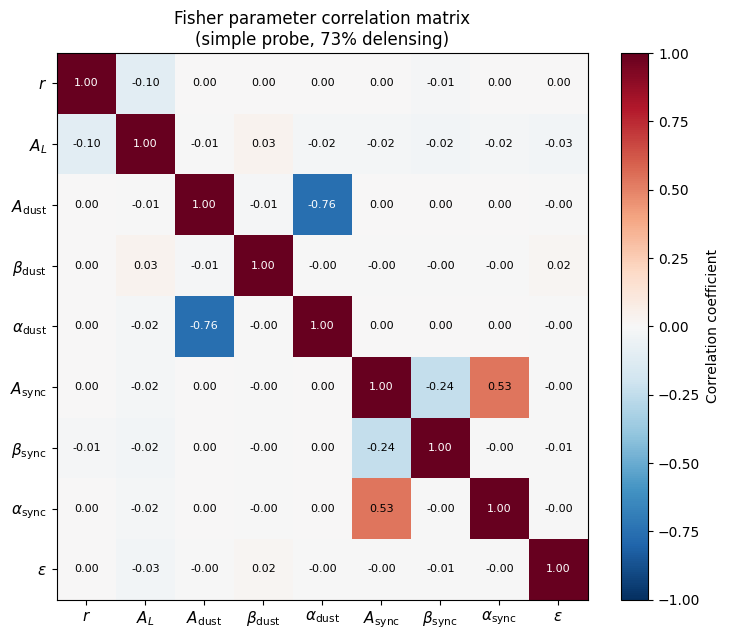

In [13]:
# Fisher correlation matrix heatmap
F_inv  = np.array(ff_cov.inverse)
names  = ff_cov.free_parameter_names
n_p    = len(names)
D      = np.sqrt(np.diag(F_inv))
corr   = F_inv / np.outer(D, D)

# Nicer labels
labels = [r'$r$', r'$A_L$', r'$A_{\rm dust}$', r'$\beta_{\rm dust}$',
          r'$\alpha_{\rm dust}$', r'$A_{\rm sync}$',
          r'$\beta_{\rm sync}$', r'$\alpha_{\rm sync}$', r'$\epsilon$']

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlation coefficient')
ax.set_xticks(range(n_p))
ax.set_yticks(range(n_p))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

for i in range(n_p):
    for j in range(n_p):
        val = corr[i, j]
        color = 'white' if abs(val) > 0.55 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('Fisher parameter correlation matrix\n(simple probe, 73% delensing)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Multi-patch sky model

The single-patch forecast assumes uniform foreground amplitude across `f_sky`. In reality, dust amplitude varies by orders of magnitude across the sky, and the satellite scan strategy produces non-uniform integration time.

The multi-patch module divides the sky into regions by galactic latitude, each with its own foreground amplitude scaling and noise depth, then combines the per-patch Fisher matrices with shared spectral indices but independent per-patch amplitudes.

In [ ]:
from augr.sky_patches import default_3patch_model
from augr.multipatch import MultiPatchFisher
from augr.telescope import probe_design, to_instrument

inst_mp = to_instrument(probe_design())
sky = default_3patch_model()

# Inspect the sky model: patch geometry, foreground scaling, scan depth
print(f"{'Patch':>12s}  {'f_sky':>6s}  {'A_dust x':>8s}  {'A_sync x':>8s}  {'noise_wt':>8s}")
for p in sky.patches:
    print(f"{p.name:>12s}  {p.f_sky:6.3f}  {p.A_dust_scale:8.1f}  {p.A_sync_scale:8.1f}  {p.noise_weight:8.3f}")
print(f"{'total':>12s}  {sky.total_f_sky:6.3f}")

In [ ]:
# Run the multi-patch forecast with both foreground models
fid_mp_g = dict(FIDUCIAL_BK15); fid_mp_g["A_lens"] = 0.27
fid_mp_m = dict(FIDUCIAL_MOMENT); fid_mp_m["A_lens"] = 0.27

mpf_gauss = MultiPatchFisher(
    inst_mp, GaussianForegroundModel(), CMBSpectra(), sky, fid_mp_g,
    priors=dict(DEFAULT_PRIORS),
    fixed_params=list(DEFAULT_FIXED) + ["Delta_dust"],
    signal_kwargs={"ell_max": 300},
)
mpf_gauss.compute()

mpf_moment = MultiPatchFisher(
    inst_mp, MomentExpansionModel(), CMBSpectra(), sky, fid_mp_m,
    priors=dict(DEFAULT_PRIORS_MOMENT),
    fixed_params=list(DEFAULT_FIXED_MOMENT),
    signal_kwargs={"ell_max": 300},
)
mpf_moment.compute()

print(mpf_gauss.summary("Probe, 3-patch, Gaussian"))
print()
print(mpf_moment.summary("Probe, 3-patch, Moment"))

In [ ]:
# sigma(r) vs cumulative sky fraction
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mpf, title in [
    (axes[0], mpf_gauss, "Gaussian FG"),
    (axes[1], mpf_moment, "Moment expansion FG"),
]:
    curve = mpf.sigma_vs_fsky_curve()
    f_skys = [e["f_sky"] for e in curve]
    sigma_rs = [e["sigma_r"] for e in curve]
    patch_labels = ["\n+ ".join(e["patches"]) for e in curve]

    ax.semilogy(f_skys, sigma_rs, "o-", color="C0", ms=8, lw=2)
    for x, y, label in zip(f_skys, sigma_rs, patch_labels):
        ax.annotate(label, (x, y), fontsize=7, ha="center",
                    xytext=(0, 12), textcoords="offset points",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

    # Also show per-patch single-patch sigma(r) as reference
    for e in curve:
        for i, (pname, ps) in enumerate(zip(e["patches"], e["patch_sigmas"])):
            if e["patches"][-1] == pname:  # only plot once per patch
                ax.semilogy(e["f_sky"], ps, "x", color="gray", ms=6, alpha=0.5)

    ax.set_xlabel(r"Cumulative $f_{\rm sky}$")
    ax.set_ylabel(r"$\sigma(r)$")
    ax.set_title(f"{title} — probe (conservative), 73% delensing")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

## Notes

- All $\sigma(r)$ values from this framework are **lower bounds** assuming well-behaved
  parametric foregrounds. Real foregrounds may have spatially-varying spectral indices,
  frequency decorrelation, and non-Gaussianity that degrade performance.
- The framework is useful for establishing **instrument sensitivity requirements**
  (how many detectors, what frequencies, what noise level) and for relative comparisons
  between configurations.
- For validation: this framework reproduces PICO's published $\sigma(r) \approx 2 \times 10^{-5}$
  (see `scripts/validate_pico.py`) and BICEP/Keck raw sensitivity evolution
  (see `scripts/plot_figure5.py`).